# Milestone 3 - Modelação e Avaliação

Neste notebook é realizada a fase de modelação do dataset IBM HR Analytics Employee Attrition & Performance, com o objetivo de desenvolver, treinar e avaliar modelos de aprendizagem automática capazes de prever a probabilidade de abandono de colaboradores (Attrition).

Esta etapa enquadra-se nas fases de Modelling e Evaluation da metodologia CRISP-DM, dando continuidade ao trabalho desenvolvido na Milestone 2, onde os dados foram explorados, limpos e preparados para modelação.

Após a análise exploratória e engenharia de atributos realizadas anteriormente, esta fase tem como propósito:

- Definir a estratégia de modelação, incluindo a divisão dos dados em conjuntos de treino e teste;
- Selecionar métricas de avaliação adequadas ao problema de negócio, com especial foco na identificação da classe minoritária (Attrition = Yes);
- Implementar um modelo baseline para estabelecer um ponto de referência de desempenho;
- Treinar e comparar diferentes algoritmos de classificação supervisionada;
- Aplicar técnicas de validação cruzada (Cross-Validation) para garantir a robustez dos resultados;
- Otimizar os modelos através de ajuste de hiperparâmetros (Hyperparameter Tuning);
- Avaliar o desempenho dos modelos com base em métricas relevantes (Recall, F1-score, ROC-AUC) e na análise da matriz de confusão;
- Analisar a importância das variáveis (Feature Importance), identificando os principais fatores que influenciam a previsão de atrito;
- Diagnosticar o comportamento dos modelos, identificando sinais de overfitting ou underfitting;
- Selecionar o modelo final com base no equilíbrio entre desempenho, robustez e interpretabilidade.

Esta fase é crítica para garantir que o modelo desenvolvido não só apresenta bom desempenho estatístico, mas também gera valor para o negócio, permitindo apoiar decisões estratégicas na gestão de recursos humanos, nomeadamente na retenção de talento.

**Autores: Luís Figueira, Martim Ferreira e Mateus Afonso**

# Baseline Clustering - K-Means
Modelo baseline de clustering com K-Means (k=5, parâmetros default).

In [1]:
# 1. IMPORTAÇÕES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score
)

import warnings
warnings.filterwarnings("ignore")
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [2]:
# 2. CARREGAMENTO DO DATASET

#url = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/dataset_processed.csv"
#df = pd.read_csv(url)
#print(f"Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")

In [3]:
# 3. PREPARAÇÃO DAS FEATURES
# Clustering

#cols_remover = ["Attrition", "Attrition_bin", "OverTime", "Gender",
#                "BusinessTravel", "Department", "EducationField",
#                "JobRole", "MaritalStatus"]

#cols_remover = [c for c in cols_remover if c in df.columns]
#df_cluster = df.drop(columns=cols_remover)

#X = df_cluster.select_dtypes(include=[np.number])

#print(f"Features utilizadas: {X.shape[1]}")
#print(f"Colunas: {list(X.columns)}")

In [4]:
# 4. GUARDAR DATASET CLUSTERING - Gerar
#import os
#import zipfile
#from IPython.display import FileLink, display

#treino_path = "data/processed/Objetivo3/treino"

# Criar a pasta e guardar
#os.makedirs(treino_path, exist_ok=True)
#X.to_csv(f"{treino_path}/X.csv", index=False)

# Criar ZIP com a estrutura de pastas completa
#zip_path = "data/processed/Objetivo3/splits.zip"
#with zipfile.ZipFile(zip_path, "w") as zipf:
#    zipf.write(f"{treino_path}/X.csv", "treino/X.csv")

#print("Splits gerados! Faz download do ZIP abaixo:")
#display(FileLink(zip_path))
# Autor: Figueira, L.

In [5]:
# 4. CARREGAR DATASET CLUSTERING DO GITHUB
base_cluster = "https://raw.githubusercontent.com/LuiscnFigueira/Projeto-cdg-grupo10/main/data/processed/Objetivo3/treino"

# Carregar diretamente do GitHub 
X = pd.read_csv(f"{base_cluster}/X.csv")

print(f"Dataset carregado: {X.shape[0]} linhas, {X.shape[1]} colunas")
# Autor: Figueira, L.

Dataset carregado: 1470 linhas, 53 colunas


In [6]:
# 4.1 NORMALIZAÇÃO — OBRIGATÓRIA PARA K-MEANS
# K-Means usa distâncias euclidianas
# Sem StandardScaler, variáveis com maior escala dominam o cálculo

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("StandardScaler aplicado.")
print(f"  Media apos escala:         {X_scaled.mean():.4f}  (deve ser ~0)")
print(f"  Desvio padrao apos escala: {X_scaled.std():.4f}  (deve ser ~1)")

StandardScaler aplicado.
  Media apos escala:         -0.0000  (deve ser ~0)
  Desvio padrao apos escala: 1.0000  (deve ser ~1)


In [7]:
# 5. MODELO BASELINE — K-MEANS K=5 (parâmetros default)
# Ponto de partida — referencial mínimo de comparação
# k=5 como valor inicial arbitrário antes de otimizar

kmeans_base = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans_base.fit_predict(X_scaled)

silhouette_base = silhouette_score(X_scaled, clusters)
inercia_base    = kmeans_base.inertia_
davies_base     = davies_bouldin_score(X_scaled, clusters)
calinski_base   = calinski_harabasz_score(X_scaled, clusters)

print("===== BASELINE — K-Means k=5 (default) =====")
print(f"  Inercia:                {inercia_base:.2f}")
print(f"  Silhouette Score:       {silhouette_base:.4f}")
print(f"  Davies-Bouldin Index:   {davies_base:.4f}")
print(f"  Calinski-Harabasz:      {calinski_base:.2f}")
print(f"  (Meta do projeto: Silhouette > 0.50)")
print()
print("Distribuicao dos clusters:")
print(pd.Series(clusters).value_counts().sort_index().to_string())

===== BASELINE — K-Means k=5 (default) =====
  Inercia:                62283.74
  Silhouette Score:       0.0826
  Davies-Bouldin Index:   2.9052
  Calinski-Harabasz:      91.89
  (Meta do projeto: Silhouette > 0.50)

Distribuicao dos clusters:
0    191
1    399
2    511
3     57
4    312


In [8]:
# 6. MÉTRICAS DO BASELINE — EXPLICAÇÃO
# No clustering não há treino/teste como na classificação
# A avaliação é feita com métricas internas

print("===== MÉTRICAS DO BASELINE =====")
print()
print(f"  Inercia (WCSS):           {inercia_base:.2f}")
print(f"    -> Soma das distancias quadraticas ao centroide")
print(f"    -> Quanto menor, mais compactos os clusters")
print()
print(f"  Silhouette Score:         {silhouette_base:.4f}")
print(f"    -> Varia entre -1 e 1 (quanto maior melhor)")
print(f"    -> Mede coesao interna e separacao entre clusters")
print(f"    -> Meta do projeto: > 0.50")
print()
print(f"  Davies-Bouldin Index:     {davies_base:.4f}")
print(f"    -> Quanto menor melhor (minimo = 0)")
print(f"    -> Mede a razao entre dispersao intra-cluster e separacao inter-cluster")
print()
print(f"  Calinski-Harabasz Index:  {calinski_base:.2f}")
print(f"    -> Quanto maior melhor")
print(f"    -> Racio entre a dispersao inter-cluster e intra-cluster")
print()
if silhouette_base > 0.50:
    print("  -> META ATINGIDA com k=5 baseline")
else:
    print("  -> Meta nao atingida — otimizacao do k necessaria (fase seguinte)")

===== MÉTRICAS DO BASELINE =====

  Inercia (WCSS):           62283.74
    -> Soma das distancias quadraticas ao centroide
    -> Quanto menor, mais compactos os clusters

  Silhouette Score:         0.0826
    -> Varia entre -1 e 1 (quanto maior melhor)
    -> Mede coesao interna e separacao entre clusters
    -> Meta do projeto: > 0.50

  Davies-Bouldin Index:     2.9052
    -> Quanto menor melhor (minimo = 0)
    -> Mede a razao entre dispersao intra-cluster e separacao inter-cluster

  Calinski-Harabasz Index:  91.89
    -> Quanto maior melhor
    -> Racio entre a dispersao inter-cluster e intra-cluster

  -> Meta nao atingida — otimizacao do k necessaria (fase seguinte)


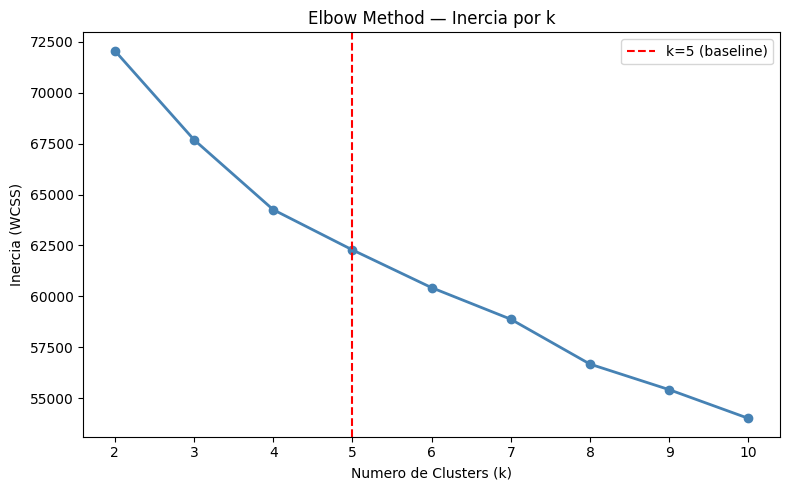

Inercia por k:
  k=2: 72067.71
  k=3: 67694.41
  k=4: 64259.25
  k=5: 62283.74  <-- baseline
  k=6: 60429.27
  k=7: 58878.65
  k=8: 56674.55
  k=9: 55419.37
  k=10: 54009.59


In [9]:
# 7. ELBOW METHOD — INÉRCIA POR K
# Ajuda a escolher o k ideal: procura o 'cotovelo' na curva

K_RANGE = range(2, 11)
inercias = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_RANGE), inercias, marker="o", color="steelblue", linewidth=2)
ax.axvline(5, color="red", linestyle="--", linewidth=1.5, label="k=5 (baseline)")
ax.set_xlabel("Numero de Clusters (k)")
ax.set_ylabel("Inercia (WCSS)")
ax.set_title("Elbow Method — Inercia por k")
ax.set_xticks(list(K_RANGE))
ax.legend()
plt.tight_layout()
plt.savefig("elbow_method.png", dpi=150, bbox_inches="tight")
plt.show()

print("Inercia por k:")
for k, iner in zip(K_RANGE, inercias):
    marker = "  <-- baseline" if k == 5 else ""
    print(f"  k={k}: {iner:.2f}{marker}")

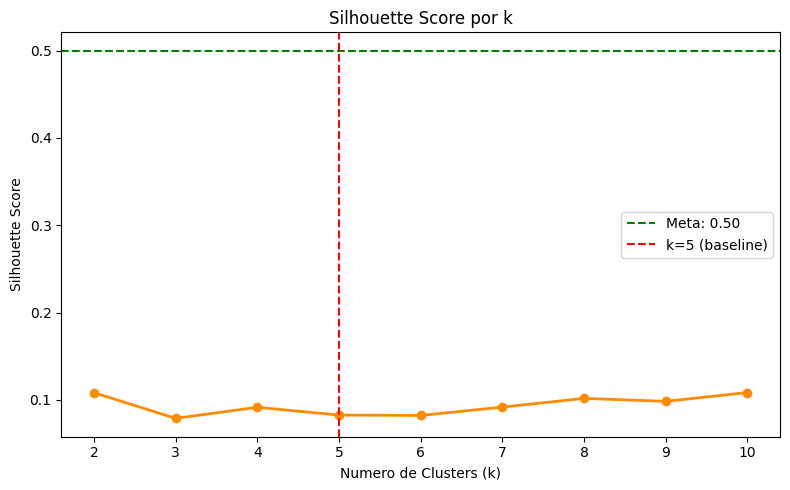

Silhouette Score por k:
  k=2: 0.1082
  k=3: 0.0788
  k=4: 0.0915
  k=5: 0.0826  <-- baseline
  k=6: 0.0821
  k=7: 0.0916
  k=8: 0.1017
  k=9: 0.0983
  k=10: 0.1083

  Melhor k por Silhouette: 10 (0.1083)


In [10]:
# 8. SILHOUETTE SCORE POR K
# Permite identificar o k com melhor separacao entre clusters

silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_RANGE), silhouettes, marker="o", color="darkorange", linewidth=2)
ax.axhline(0.50, color="green", linestyle="--", linewidth=1.5, label="Meta: 0.50")
ax.axvline(5, color="red", linestyle="--", linewidth=1.5, label="k=5 (baseline)")
ax.set_xlabel("Numero de Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score por k")
ax.set_xticks(list(K_RANGE))
ax.legend()
plt.tight_layout()
plt.savefig("silhouette_por_k.png", dpi=150, bbox_inches="tight")
plt.show()

print("Silhouette Score por k:")
for k, sil in zip(K_RANGE, silhouettes):
    marker = "  <-- baseline" if k == 5 else ""
    print(f"  k={k}: {sil:.4f}{marker}")

melhor_k = list(K_RANGE)[silhouettes.index(max(silhouettes))]
print(f"\n  Melhor k por Silhouette: {melhor_k} ({max(silhouettes):.4f})")

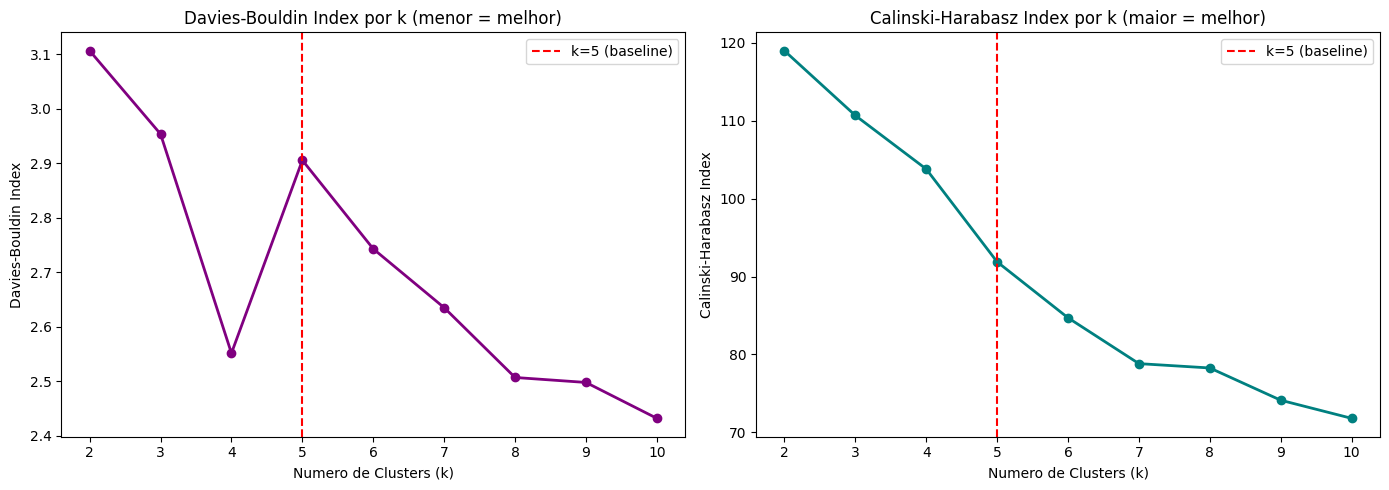

Davies-Bouldin e Calinski-Harabasz por k:
    k    Davies-Bouldin   Calinski-Harabasz
  ------------------------------------------
    2            3.1061              119.01
    3            2.9532              110.69
    4            2.5511              103.81
    5            2.9052               91.89  <-- baseline
    6            2.7425               84.70
    7            2.6346               78.81
    8            2.5066               78.26
    9            2.4974               74.11
   10            2.4316               71.79


In [11]:
# 9. DAVIES-BOULDIN E CALINSKI-HARABASZ POR K

db_scores = []
ch_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), db_scores, marker="o", color="purple", linewidth=2)
axes[0].axvline(5, color="red", linestyle="--", linewidth=1.5, label="k=5 (baseline)")
axes[0].set_xlabel("Numero de Clusters (k)")
axes[0].set_ylabel("Davies-Bouldin Index")
axes[0].set_title("Davies-Bouldin Index por k (menor = melhor)")
axes[0].set_xticks(list(K_RANGE))
axes[0].legend()

axes[1].plot(list(K_RANGE), ch_scores, marker="o", color="teal", linewidth=2)
axes[1].axvline(5, color="red", linestyle="--", linewidth=1.5, label="k=5 (baseline)")
axes[1].set_xlabel("Numero de Clusters (k)")
axes[1].set_ylabel("Calinski-Harabasz Index")
axes[1].set_title("Calinski-Harabasz Index por k (maior = melhor)")
axes[1].set_xticks(list(K_RANGE))
axes[1].legend()

plt.tight_layout()
plt.savefig("davies_calinski_por_k.png", dpi=150, bbox_inches="tight")
plt.show()

print("Davies-Bouldin e Calinski-Harabasz por k:")
print(f"  {'k':>3}  {'Davies-Bouldin':>16}  {'Calinski-Harabasz':>18}")
print(f"  {'-'*42}")
for k, db, ch in zip(K_RANGE, db_scores, ch_scores):
    marker = "  <-- baseline" if k == 5 else ""
    print(f"  {k:>3}  {db:>16.4f}  {ch:>18.2f}{marker}")

In [12]:
# 10. TABELA COMPARATIVA — TODAS AS MÉTRICAS POR K

df_metricas = pd.DataFrame({
    "k":                  list(K_RANGE),
    "Inercia":            inercias,
    "Silhouette":         silhouettes,
    "Davies-Bouldin":     db_scores,
    "Calinski-Harabasz": ch_scores,
}).round(4)

df_metricas["baseline"] = df_metricas["k"].apply(lambda x: "<--" if x == 5 else "")

print("===== TABELA COMPARATIVA — MÉTRICAS POR K =====")
display(df_metricas)

===== TABELA COMPARATIVA — MÉTRICAS POR K =====


,k,Inercia,Silhouette,Davies-Bouldin,Calinski-Harabasz,baseline
0,2,72067.7110,0.1082,3.1061,119.0059,
1,3,67694.4081,0.0788,2.9532,110.6906,
2,4,64259.2518,0.0915,2.5511,103.8086,
3,5,62283.7359,0.0826,2.9052,91.8879,<--
4,6,60429.2714,0.0821,2.7425,84.7000,
5,7,58878.6505,0.0916,2.6346,78.8143,
6,8,56674.5470,0.1017,2.5066,78.2569,
7,9,55419.3721,0.0983,2.4974,74.1140,
8,10,54009.5906,0.1083,2.4316,71.7868,


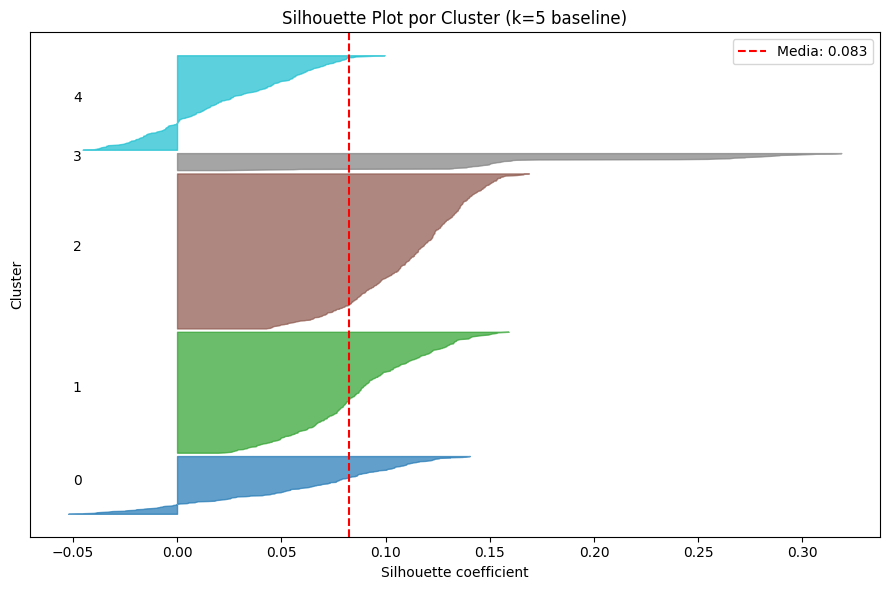

Silhouette medio por cluster:
  Cluster 0: 0.0582  (n=191)
  Cluster 1: 0.0881  (n=399)
  Cluster 2: 0.1116  (n=511)
  Cluster 3: 0.1885  (n=57)
  Cluster 4: 0.0235  (n=312)


In [13]:
# 11. SILHOUETTE PLOT POR CLUSTER (k=5 baseline)
# Visualiza o silhouette de cada observação dentro de cada cluster
# Barras longas e uniformes = cluster bem definido

sample_silhouette_values = silhouette_samples(X_scaled, clusters)
n_clusters = 5

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    cluster_silhouette = sample_silhouette_values[clusters == i]
    cluster_silhouette.sort()
    size_cluster = cluster_silhouette.shape[0]
    y_upper = y_lower + size_cluster

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, cluster_silhouette,
        facecolor=colors[i], edgecolor=colors[i], alpha=0.7
    )
    ax.text(-0.05, y_lower + 0.5 * size_cluster, str(i), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(silhouette_base, color="red", linestyle="--", linewidth=1.5,
           label=f"Media: {silhouette_base:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster")
ax.set_title("Silhouette Plot por Cluster (k=5 baseline)")
ax.set_yticks([])
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("silhouette_plot_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

print("Silhouette medio por cluster:")
for i in range(n_clusters):
    vals = sample_silhouette_values[clusters == i]
    print(f"  Cluster {i}: {vals.mean():.4f}  (n={len(vals)})")

In [14]:
# 12. CARACTERIZAÇÃO DOS CLUSTERS

# Criar dataframe temporário com X e clusters para análise
df_perfil = X.copy()
df_perfil["cluster"] = clusters

cols_perfil = []
for col in ["Age", "MonthlyIncome", "JobLevel", "TotalWorkingYears",
            "YearsAtCompany", "SatisfactionIndex", "WorkLifeBalance",
            "OverTime_bin", "IncomePerLevel", "RatioYearsInRole",
            "Attrition_bin"]:
    if col in df_perfil.columns:
        cols_perfil.append(col)

print("===== PERFIL MEDIO POR CLUSTER =====")
perfil = df_perfil.groupby("cluster")[cols_perfil].mean().round(3)
display(perfil)

===== PERFIL MEDIO POR CLUSTER =====


,Age,MonthlyIncome,JobLevel,TotalWorkingYears,YearsAtCompany,SatisfactionIndex,WorkLifeBalance,OverTime_bin,IncomePerLevel,RatioYearsInRole
cluster,,,,,,,,,,
0,46.021,16294.068,4.115,23.696,13.853,2.162,2.791,0.288,3977.309,0.532
1,35.160,5900.125,2.035,9.331,6.180,2.163,2.827,0.288,2842.116,0.610
2,33.804,3135.845,1.170,7.063,4.366,2.137,2.679,0.288,2742.592,0.546
3,36.789,5474.649,1.754,9.754,5.912,2.123,2.930,0.263,2906.492,0.580
4,38.744,6982.436,2.365,13.356,8.404,2.224,2.763,0.269,2918.854,0.619


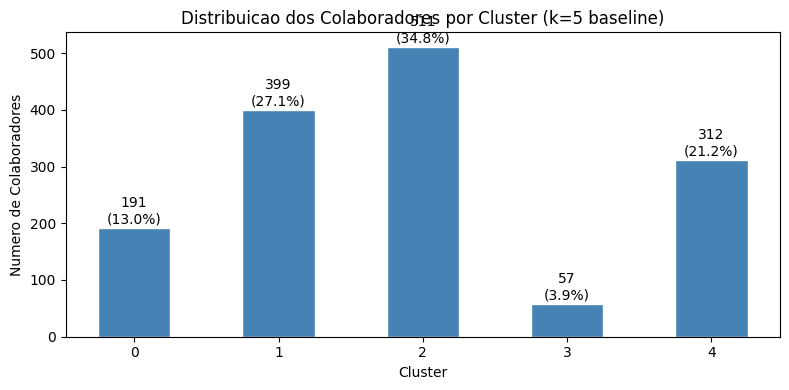

In [15]:
# 13.1 Distribuição dos clusters
contagem = pd.Series(clusters).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(contagem.index, contagem.values, color="steelblue", edgecolor="white", width=0.5)
for bar, val in zip(bars, contagem.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3,
            f"{val}\n({val/len(clusters)*100:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_xlabel("Cluster")
ax.set_ylabel("Numero de Colaboradores")
ax.set_title("Distribuicao dos Colaboradores por Cluster (k=5 baseline)")
ax.set_xticks(contagem.index)
plt.tight_layout()
plt.savefig("distribuicao_clusters_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

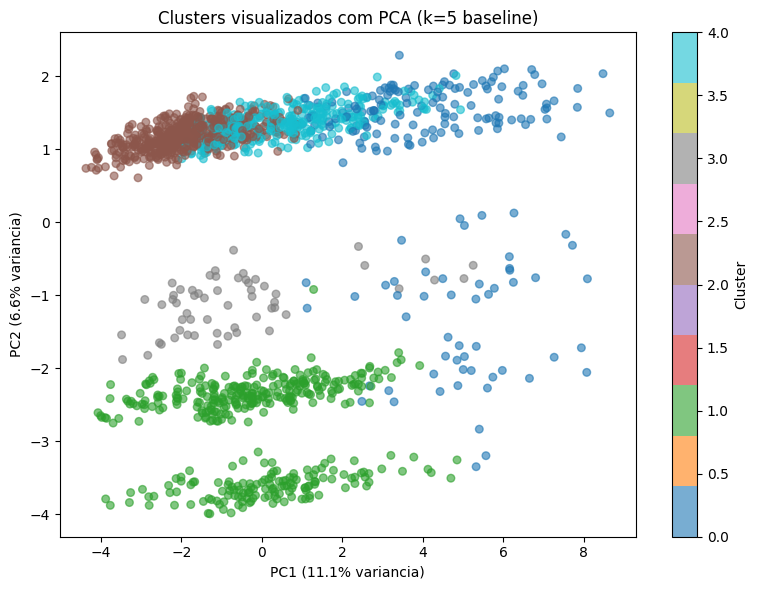

In [16]:
# 13.2 Visualização com PCA (2 componentes)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
variancia = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=clusters, cmap="tab10",
                     alpha=0.6, s=30)
ax.set_xlabel(f"PC1 ({variancia[0]*100:.1f}% variancia)")
ax.set_ylabel(f"PC2 ({variancia[1]*100:.1f}% variancia)")
ax.set_title("Clusters visualizados com PCA (k=5 baseline)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.savefig("clusters_pca_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

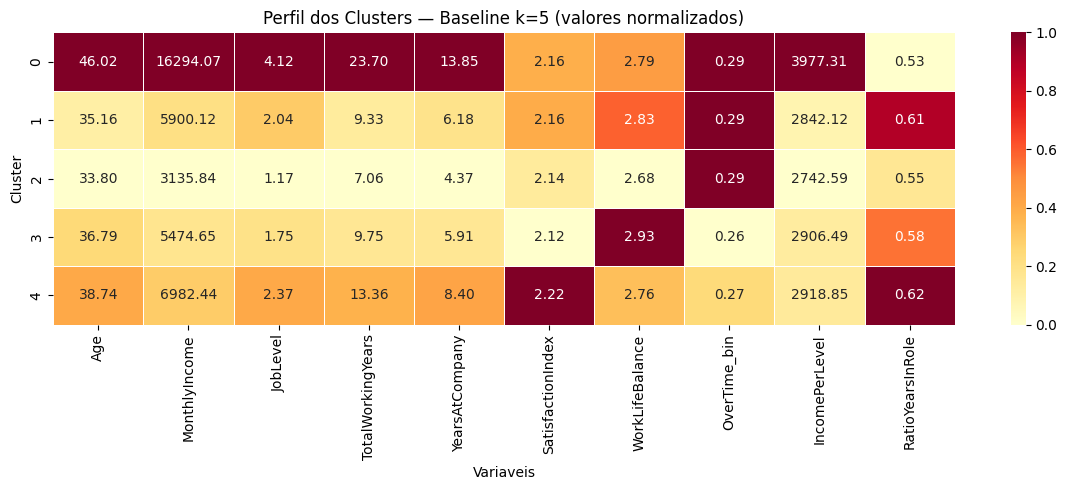

In [17]:
# 13.3 Heatmap do perfil dos clusters
fig, ax = plt.subplots(figsize=(12, 5))
perfil_norm = (perfil - perfil.min()) / (perfil.max() - perfil.min())
sns.heatmap(perfil_norm, annot=perfil.values, fmt=".2f",
            cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("Perfil dos Clusters — Baseline k=5 (valores normalizados)")
ax.set_xlabel("Variaveis")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig("heatmap_clusters_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# 13.4 Taxa de Attrition por cluster
if "Attrition_bin" in df_perfil.columns:
    attrition_cluster = df_perfil.groupby("cluster")["Attrition_bin"].mean() * 100
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(attrition_cluster.index, attrition_cluster.values,
                  color="coral", edgecolor="white", width=0.5)
    for bar, val in zip(bars, attrition_cluster.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f"{val:.1f}%",
                ha="center", va="bottom", fontsize=11)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Taxa de Attrition (%)")
    ax.set_title("Taxa de Attrition por Cluster (k=5 baseline)")
    ax.set_xticks(attrition_cluster.index)
    plt.tight_layout()
    plt.savefig("attrition_por_cluster_baseline.png", dpi=150, bbox_inches="tight")
    plt.show()

In [19]:
# 14. RESUMO FINAL

print("=" * 55)
print("RESUMO — BASELINE")
print("=" * 55)
print(f"  Algoritmo:                K-Means (parâmetros default)")
print(f"  k baseline:               5")
print(f"  Normalizacao:             StandardScaler")
print()
print(f"  Inercia (WCSS):           {inercia_base:.2f}")
print(f"  Silhouette Score:         {silhouette_base:.4f}")
print(f"  Davies-Bouldin Index:     {davies_base:.4f}")
print(f"  Calinski-Harabasz Index:  {calinski_base:.2f}")
print(f"  Meta Silhouette (> 0.50): {'ATINGIDA' if silhouette_base > 0.50 else 'NAO ATINGIDA'}")
print()
for c in sorted(np.unique(clusters)):
    n = (clusters == c).sum()
    print(f"  Cluster {c}: {n} colaboradores ({n/len(clusters)*100:.1f}%)")
print()
print("  -> Referencial minimo para a otimizacao do k (fase seguinte).")
print("=" * 55)

RESUMO — BASELINE
  Algoritmo:                K-Means (parâmetros default)
  k baseline:               5
  Normalizacao:             StandardScaler

  Inercia (WCSS):           62283.74
  Silhouette Score:         0.0826
  Davies-Bouldin Index:     2.9052
  Calinski-Harabasz Index:  91.89
  Meta Silhouette (> 0.50): NAO ATINGIDA

  Cluster 0: 191 colaboradores (13.0%)
  Cluster 1: 399 colaboradores (27.1%)
  Cluster 2: 511 colaboradores (34.8%)
  Cluster 3: 57 colaboradores (3.9%)
  Cluster 4: 312 colaboradores (21.2%)

  -> Referencial minimo para a otimizacao do k (fase seguinte).
